# Standalone Flow Matching code

In [1]:
import torch
from torch import nn,Tensor
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_blobs,make_circles
device = torch.device( 'cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


\begin{aligned}
    \frac{d}{dt}X_t &= u_t(X_t)\\
\end{aligned}

In [2]:
class Flow(nn.Module):
    def __init__(self,dim:int=2,h:int=64):
        super().__init__()
        self.net=nn.Sequential(
        nn.Linear(dim+ 1,h),nn.ELU(),
        nn.Linear(h,h),nn.ELU(),
        nn.Linear(h,h),nn.ELU(),
        nn.Linear(h,dim))
    
    def forward(self,x_t:Tensor,t:Tensor)->Tensor:
        """ this function approches u_t, takes in:
            t:shape(batch,1)
            x_t:shape(batch,dim) """

        return self.net(torch.cat((t,x_t),-1))
    def step(self,x_t:Tensor,t_start:Tensor,t_end:Tensor)->Tensor:
        t_start=t_start.view(1, 1).expand(x_t.shape[0], 1)
        #Forsimplicity,usingmidpointODEsolverinthisexample
        return x_t+(t_end-t_start)* self(x_t+self(x_t,t_start)*(t_end-t_start)/2,
        t_start+(t_end-t_start)/2)

In [3]:
 #training
flow = Flow()
optimizer = torch.optim.Adam(flow.parameters(), 5e-4)
loss_fn = nn.MSELoss()

x_1 =Tensor(make_circles(n_samples=1000, noise=0.1, random_state=42)[0])

num_epochs = 10000
batch_size = 256

for epoch in range(num_epochs):
    indices = torch.randperm(len(x_1))[:batch_size]
    x_1_batch = x_1[indices]
    x_0_batch = torch.randn_like(x_1_batch)
    
    t = torch.rand(batch_size, 1)
    x_t = (1-t) * x_0_batch + t * x_1_batch
    dx_t = x_1_batch - x_0_batch
    
    optimizer.zero_grad()
    loss = loss_fn(flow(x_t, t), dx_t)
    loss.backward()
    optimizer.step()
    
    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")


Epoch 0, Loss: 1.323003
Epoch 1000, Loss: 0.980673
Epoch 2000, Loss: 0.925100
Epoch 3000, Loss: 0.874710
Epoch 4000, Loss: 0.915825
Epoch 5000, Loss: 0.881559
Epoch 6000, Loss: 0.875388
Epoch 7000, Loss: 0.973853
Epoch 8000, Loss: 1.016741
Epoch 9000, Loss: 0.958441


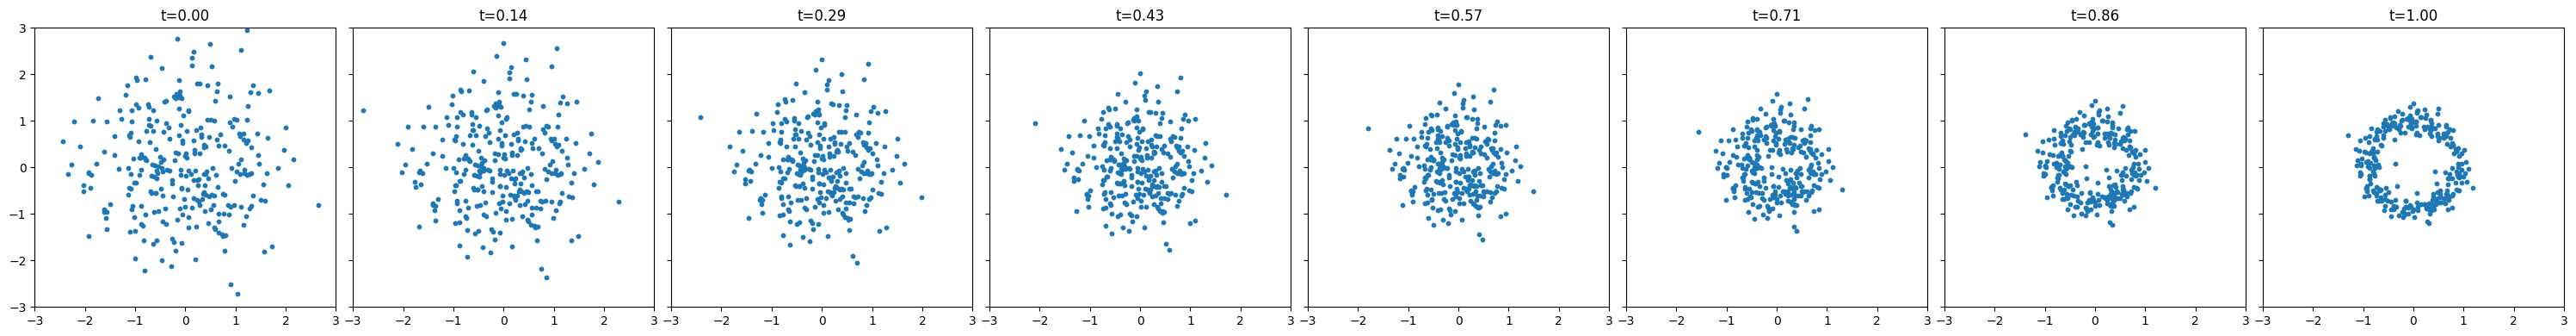

In [18]:

#sampling
x=torch.randn(300,2)
n_steps= 7
fig,axes=plt.subplots(1,n_steps+ 1,figsize=(30,4),sharex=True,sharey=True)
time_steps=torch.linspace(0, 1.0,n_steps+ 1)
axes[0].scatter(x.detach()[:,0],x.detach()[:, 1],s=10)
axes[0].set_title(f't={time_steps[0]:.2f}')
axes[0].set_xlim(-3.0,3.0)
axes[0].set_ylim(-3.0,3.0)
for i in range(n_steps):
    x=flow.step(x,time_steps[i],time_steps[i+ 1])
    axes[i+ 1].scatter(x.detach()[:,0],x.detach()[:, 1],s=10)
    axes[i+ 1].set_title(f't={time_steps[i+ 1]:.2f}')
plt.tight_layout()
plt.show()

Saved as flow_sampling.gif


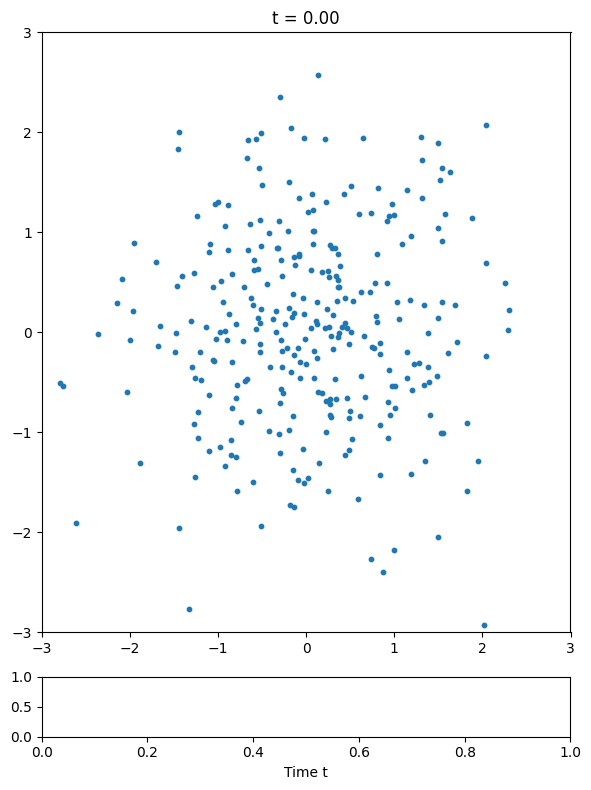

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from matplotlib.animation import PillowWriter
# Sampling with frame storage
x = torch.randn(300, 2)
n_steps = 50  # More steps for smoother animation
time_steps = torch.linspace(0, 1.0, n_steps + 1)

frames = []
frames.append(x.detach().clone())

for i in range(n_steps):
    x = flow.step(x, time_steps[i], time_steps[i + 1])
    frames.append(x.detach().clone())

# Create animation
fig, (ax_scatter, ax_bar) = plt.subplots(2, 1, figsize=(6, 8), 
                                          gridspec_kw={'height_ratios': [10, 1]})

scatter = ax_scatter.scatter(frames[0][:, 0], frames[0][:, 1], s=10)
ax_scatter.set_xlim(-3.0, 3.0)
ax_scatter.set_ylim(-3.0, 3.0)
ax_scatter.set_title(f't = {time_steps[0]:.2f}')

ax_bar.set_xlim(0, 1)
ax_bar.set_ylim(0, 1)
ax_bar.set_xlabel('Time t')
bar_fill = ax_bar.barh(0.5, 0, height=0.5, color='blue')

def update(frame_idx):
    scatter.set_offsets(frames[frame_idx].numpy())
    ax_scatter.set_title(f't = {time_steps[frame_idx]:.2f}')
    bar_fill[0].set_width(time_steps[frame_idx])

ani = FuncAnimation(fig, update, frames=len(frames), interval=100)
plt.tight_layout()

# Save as GIF
writer = PillowWriter(fps=10)
ani.save('flow_sampling.gif', writer=writer, dpi=100)
print("Saved as flow_sampling.gif")